**HYPOTHESIS H5 — SEASONALITY**

Shark incidents show seasonal patterns, with some months or seasons having higher recorded incident frequencies.

---

***Which seasons show the highest frequency of recorded shark incidents?***

The analysis of the relationship between **seasons and recorded shark incidents** examines whether shark encounters are distributed evenly throughout the year or whether certain seasons show higher incident frequencies.

In [5]:
from google.colab import files

uploaded = files.upload()

Saving GSAF5.xls to GSAF5.xls


In [12]:
import pandas as pd

In [13]:
df = pd.read_excel("GSAF5.xls")
shark_df = pd.read_excel("GSAF5.xls")

In [14]:
display(shark_df)

,Date,Year,Type,Country,State,Location,Activity,Name,Sex,Age,...,Species,Source,pdf,href formula,href,Case Number,Case Number.1,original order,Unnamed: 21,Unnamed: 22
0,23rd June,2026.0,Unprovoked,Bahamas,Staniel Cay,Exhuma Cays,Swimming,Unknown,M,12,...,Unknown,Keith Cowley: Kevin McMurray Trackingsharks.co...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,13th June,2026.0,Unprovoked,USA,Florida,Reservation Way near Indian Pass,Swimming,Keira Ralph,F,17,...,Unknown small shark,Keith Cowley: Simon De Marchi: All things Emer...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,13th June,2026.0,Unprovoked,Australia,NSW,Coogee Beach,Swimming,Leah Stewart,F,35,...,Great White Shark 4m,Simon De Marchi: Andrew Currie: ABC NEWS: 9 Ne...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,11th June,2026.0,Unprovoked,Galapogos Islands,Santa Fe Island,Mosquera Islet,Snorkeling,Australia Woman,F,?,...,Unknown,Andrew Currie: Facebook: AbsolutCruceros,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,8th June,2026.0,Unprovoked,USA,Florida,Panama City,Swimming,Unknown,M,20's,...,2.4m (8ft) Bull shark,James Kingsley:Todd Smith: Kevin McMurray Trac...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7098,Before 1903,0.0,Unprovoked,AUSTRALIA,Western Australia,Roebuck Bay,Diving,male,M,NaN,...,NaN,"H. Taunton; N. Bartlett, p. 234",ND-0005-RoebuckBay.pdf,http://sharkattackfile.net/spreadsheets/pdf_di...,http://sharkattackfile.net/spreadsheets/pdf_di...,ND.0005,ND.0005,6.0,NaN,NaN
7099,Before 1903,0.0,Unprovoked,AUSTRALIA,Western Australia,NaN,Pearl diving,Ahmun,M,NaN,...,NaN,"H. Taunton; N. Bartlett, pp. 233-234",ND-0004-Ahmun.pdf,http://sharkattackfile.net/spreadsheets/pdf_di...,http://sharkattackfile.net/spreadsheets/pdf_di...,ND.0004,ND.0004,5.0,NaN,NaN
7100,1900-1905,0.0,Unprovoked,USA,North Carolina,Ocracoke Inlet,Swimming,Coast Guard personnel,M,NaN,...,NaN,"F. Schwartz, p.23; C. Creswell, GSAF",ND-0003-Ocracoke_1900-1905.pdf,http://sharkattackfile.net/spreadsheets/pdf_di...,http://sharkattackfile.net/spreadsheets/pdf_di...,ND.0003,ND.0003,4.0,NaN,NaN
7101,1883-1889,0.0,Unprovoked,PANAMA,NaN,"Panama Bay 8ºN, 79ºW",NaN,Jules Patterson,M,NaN,...,NaN,"The Sun, 10/20/1938",ND-0002-JulesPatterson.pdf,http://sharkattackfile.net/spreadsheets/pdf_di...,http://sharkattackfile.net/spreadsheets/pdf_di...,ND.0002,ND.0002,3.0,NaN,NaN


**Analysis Plan**
  - Extract and standardize the Date/Year information to identify the season of each recorded incident.
	- Clean and standardize relevant date and location fields.
	- Identify the seasons with the highest and lowest numbers of recorded incidents.

**Create a final comparison table including:**

Season
Total incidents
Percentage of total incidents

In [15]:
print("DATE COLUMNS:")
print([c for c in shark_df.columns if "date" in c.lower()])

print("\nYEAR COLUMNS:")
print([c for c in shark_df.columns if "year" in c.lower()])

print("\nTYPE:")
print([c for c in shark_df.columns if any(word in c.lower() for word in ["type"])])

DATE COLUMNS:
['Date']

YEAR COLUMNS:
['Year']

TYPE:
['Type']


In [16]:
display(
    shark_df[
        ["Date", "Year", "Type", "Fatal Y/N"]
    ].head(10)
)

,Date,Year,Type,Fatal Y/N
0,23rd June,2026.0,Unprovoked,N
1,13th June,2026.0,Unprovoked,N
2,13th June,2026.0,Unprovoked,N
3,11th June,2026.0,Unprovoked,N
4,8th June,2026.0,Unprovoked,N
5,6th June,2026.0,Unprovoked,Y
6,5th June,2026.0,Provoked,N
7,1st June,2026.0,Unprovoked,N
8,1st June,2026.0,Unprovoked,N
9,31st May,2026.0,Unprovoked,N


/tmp/ipykernel_2072/741183435.py:38: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Month_Name', y='Total incidents', data=month_incidents, palette='viridis')


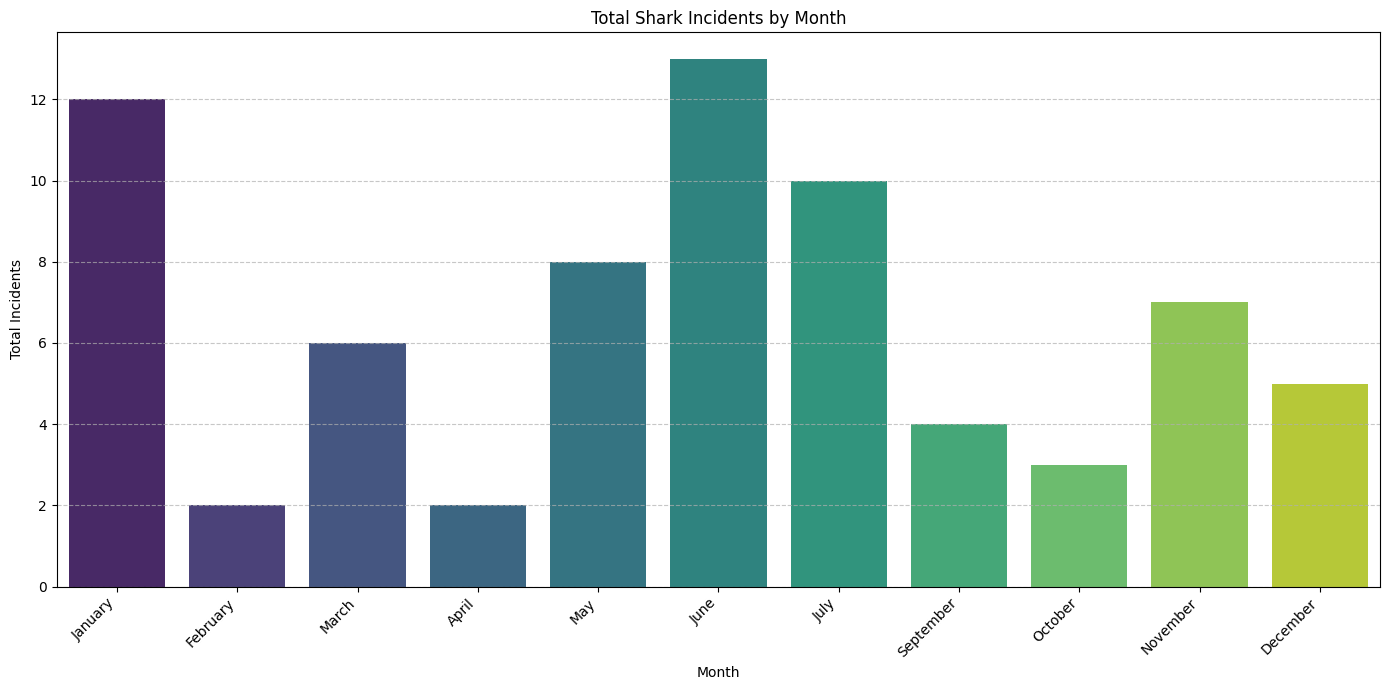

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
shark_df = pd.read_excel("GSAF5.xls")

def clean_date_string(date_str):
    if pd.isna(date_str):
        return date_str
    date_str = str(date_str).replace('th', '').replace('nd', '').replace('rd', '').replace('st', '').strip()
    return date_str

shark_df['Date_cleaned'] = shark_df['Date'].apply(clean_date_string)

shark_df['Year_numeric'] = pd.to_numeric(shark_df['Year'], errors='coerce')

shark_df['Full_Date_Str'] = shark_df.apply(
    lambda row: f"{row['Date_cleaned']} {int(row['Year_numeric'])}"
    if pd.notna(row['Date_cleaned']) and pd.notna(row['Year_numeric']) and row['Year_numeric'] >= 1000
    else None, axis=1
)

shark_df['Incident_Date'] = pd.to_datetime(shark_df['Full_Date_Str'], errors='coerce')

shark_df['Month'] = shark_df['Incident_Date'].dt.month

month_incidents = shark_df['Month'].value_counts().reset_index()
month_incidents.columns = ['Month', 'Total incidents']

total_incidents_known_month = month_incidents['Total incidents'].sum()
month_incidents['Percentage of total incidents'] = (month_incidents['Total incidents'] / total_incidents_known_month * 100).round(2)

month_incidents = month_incidents.sort_values(by='Month', ascending=True)

month_names = ['January', 'February', 'March', 'April', 'May', 'June', 'July', 'August', 'September', 'October', 'November', 'December']
month_incidents['Month_Name'] = month_incidents['Month'].map(lambda x: month_names[int(x)-1])

plt.figure(figsize=(14, 7))
sns.barplot(x='Month_Name', y='Total incidents', data=month_incidents, palette='viridis')
plt.title('Total Shark Incidents by Month')
plt.xlabel('Month')
plt.ylabel('Total Incidents')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [20]:
display(month_incidents[['Month_Name', 'Total incidents', 'Percentage of total incidents']])

,Month_Name,Total incidents,Percentage of total incidents
1,January,12,16.67
10,February,2,2.78
5,March,6,8.33
9,April,2,2.78
3,May,8,11.11
0,June,13,18.06
2,July,10,13.89
7,September,4,5.56
8,October,3,4.17
4,November,7,9.72


Shark incidents exhibit a noticeable seasonal pattern. The data reveals a clear peak in incidents during the month of June, followed by July and January, suggesting that these months have a higher frequency of recorded shark encounters.